# PART 8

Haikal Ali_1103223071_TK46GAB

# SLC 8 — Tree-Based Algorithms and Ensemble Methods

Materi ini membahas algoritma berbasis pohon dan metode ensemble, yaitu **decision tree**, **random forest**, **gradient boosting**, tuning hyperparameter, dan perbandingan beberapa metode ensemble.

## Technical Requirements

Disarankan menggunakan environment Python yang terpisah agar pekerjaan aman dari instalasi/library Python lain.

Kebutuhan teknis:
- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub sudah di-clone dan environment Python dibuat dari file `requirements.txt`

## 1. Introduction to Decision Trees

Decision tree adalah model yang digunakan untuk klasifikasi dan regresi. Model ini bekerja dengan membagi data secara rekursif berdasarkan nilai fitur, sehingga terbentuk struktur seperti pohon. Node internal merepresentasikan keputusan berdasarkan fitur, sedangkan leaf node merepresentasikan hasil prediksi.

Decision tree populer karena mudah diinterpretasikan dan dapat menangani data numerik maupun kategorikal. Walaupun relatif mudah dipahami, decision tree tetap cukup kuat dan sering dapat mengungguli model yang lebih kompleks.

### Getting Ready

Langkah awal adalah menyiapkan library dan dataset Iris.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)

### How to Do It

Model decision tree dibuat, dilatih, digunakan untuk prediksi, lalu dievaluasi.

In [4]:
clf = DecisionTreeClassifier(random_state=2024)

In [5]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=2024)

In [6]:
y_pred = clf.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

In [8]:
report = classification_report(
    y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

In [9]:
styled_df = (report_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

In [10]:
styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


Model decision tree pada dataset Iris memiliki performa yang cukup baik meskipun menggunakan hyperparameter default.

### How It Works

Decision tree membagi dataset berdasarkan nilai fitur. Tujuan dari setiap split adalah meningkatkan homogenitas pada setiap subgroup. Kriteria split biasanya menggunakan **Gini impurity** atau **entropy**. Pada scikit-learn, Gini impurity digunakan sebagai default.

### Visualisasi Decision Tree

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

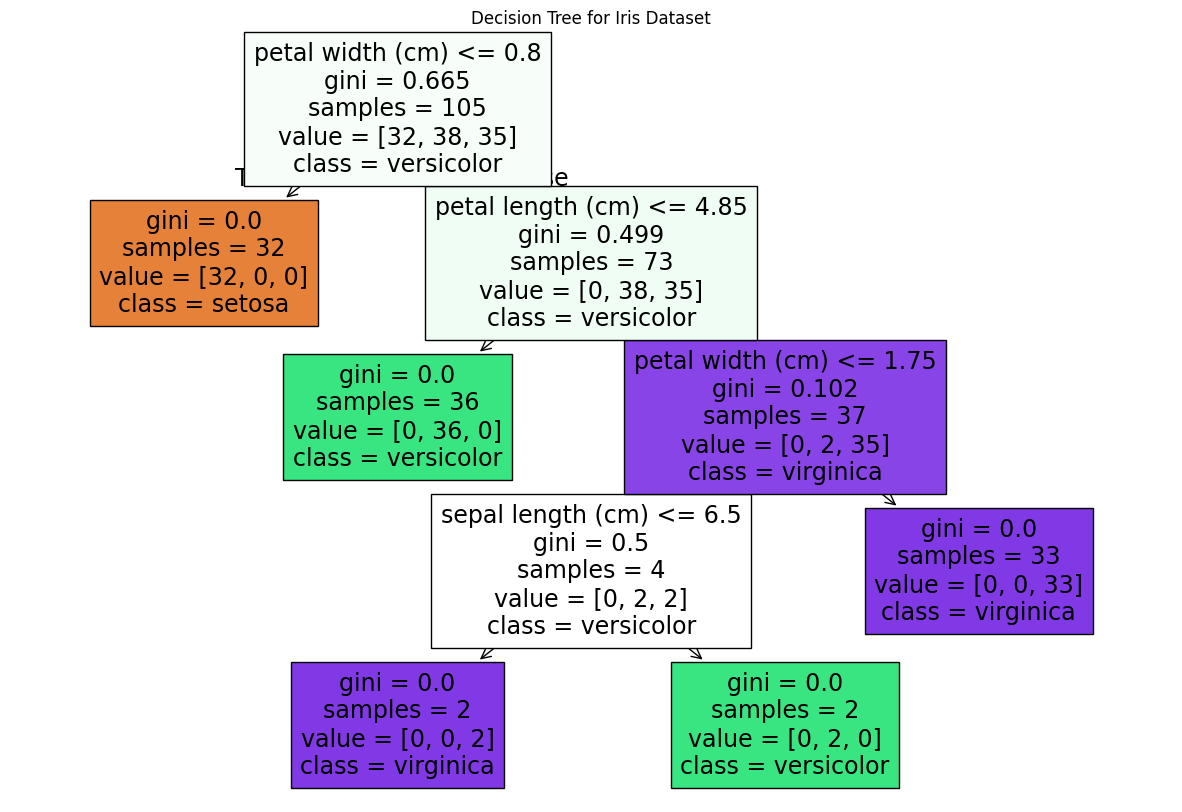

In [12]:
plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.title("Decision Tree for Iris Dataset")
plt.show()

Output decision tree memberikan informasi seperti nama fitur, Gini impurity, jumlah sampel, distribusi nilai kelas, dan kelas prediksi.

Penjelasan elemen pada tree:
- **Feature name** menunjukkan fitur yang digunakan untuk membuat keputusan.
- **Gini impurity** menunjukkan tingkat kemurnian node.
- **Samples** menunjukkan jumlah data training pada node tersebut.
- **Value** menunjukkan proporsi setiap kelas pada node.
- **Class** menunjukkan kelas dominan pada node tersebut.

### Hyperparameter Decision Tree

Beberapa hyperparameter penting pada decision tree:
- `max_depth`: mengontrol kedalaman maksimum tree.
- `min_samples_split`: jumlah minimum sampel agar node boleh di-split.
- `min_samples_leaf`: jumlah minimum sampel pada leaf node.
- `max_features`: jumlah maksimum fitur yang dipertimbangkan pada split.
- `min_impurity_decrease`: batas minimum penurunan impurity agar split dilakukan.

### Hands-on Exercises

Langkah latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset untuk klasifikasi.
3. Bagi data menjadi training dan testing.
4. Buat `DecisionTreeClassifier()` dari `sklearn.tree`.
5. Latih model dengan method `fit`.
6. Prediksi data test.
7. Evaluasi classifier menggunakan accuracy dan confusion matrix.
8. Visualisasikan decision tree dan interpretasikan split.

## 2. Random Forests and Bagging

Random forest adalah metode ensemble yang menggabungkan banyak decision tree untuk meningkatkan akurasi dan mengurangi overfitting. Random forest menggunakan teknik **bootstrap aggregating** atau **bagging**, yaitu melatih banyak tree pada subset data yang diambil dengan replacement.

Setiap tree memberikan suara prediksi, lalu prediksi akhir ditentukan berdasarkan mayoritas suara atau rata-rata prediksi dari semua tree.

### Getting Ready

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [14]:
iris = load_iris()
X = iris.data
y = iris.target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)

### How to Do It

In [16]:
rf_clf = RandomForestClassifier(
    n_estimators=100, random_state=2024)

In [17]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=2024)

In [18]:
y_pred = rf_clf.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(
    y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

In [20]:
styled_df = (report_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

In [21]:
styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.833,0.833,0.833,12
2,0.867,0.867,0.867,15
accuracy,0.911,0.911,0.911,1
macro avg,0.900,0.900,0.900,45
weighted avg,0.911,0.911,0.911,45


Random forest meningkatkan performa dibandingkan decision tree tunggal. Pada materi, accuracy decision tree adalah 0.867, sedangkan random forest mencapai 0.911.

### How It Works

Random forest membuat banyak decision tree. Setiap tree dilatih pada sampel bootstrap dari dataset. Selain itu, pada setiap split, hanya subset fitur acak yang dipertimbangkan. Pendekatan ini mengurangi variance dan meningkatkan stabilitas model.

### Feature Importance

In [22]:
import matplotlib.pyplot as plt

In [23]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

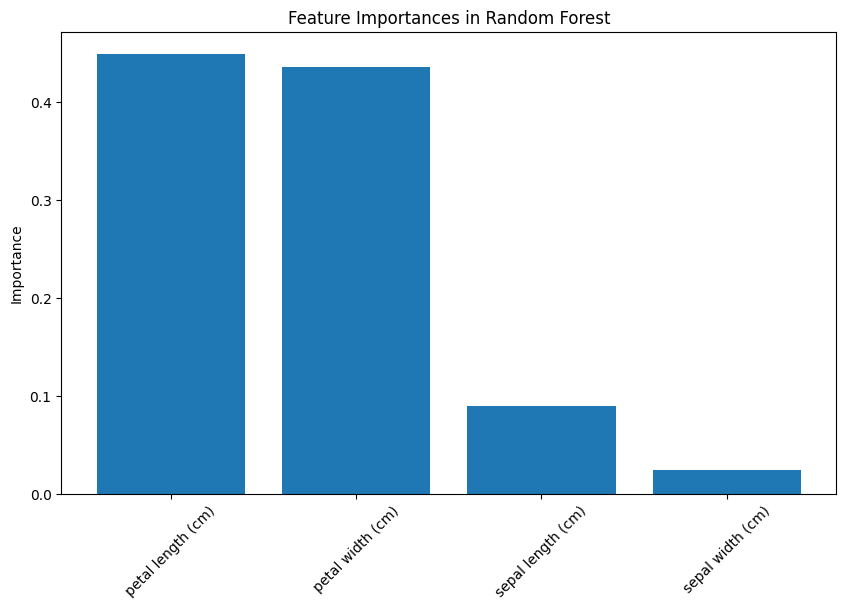

In [24]:
plt.figure(figsize=(10,6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(X.shape[1]),
        importances[indices], align="center")
plt.xticks(range(X.shape[1]),
           [iris.feature_names[i] for i in indices],
           rotation=45)
plt.ylabel("Importance")
plt.show()

Feature importance membantu memahami fitur mana yang paling berkontribusi terhadap keputusan model. Pada contoh Iris, fitur seperti `petal length (cm)` dan `petal width (cm)` menjadi fitur yang paling penting.

### There’s More

Hyperparameter random forest seperti `max_features`, `max_depth`, dan `n_estimators` dapat di-tuning untuk mengoptimalkan performa. Bagging juga dapat diterapkan pada model lain menggunakan `BaggingClassifier()` dan `BaggingRegressor()`.

### Hands-on Exercises

Langkah latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset untuk klasifikasi.
3. Bagi dataset menjadi training dan test.
4. Buat `RandomForestClassifier()` dari `sklearn.ensemble`.
5. Latih model menggunakan method `fit`.
6. Prediksi data test.
7. Evaluasi model menggunakan accuracy, precision, dan recall.
8. Visualisasikan dan analisis feature importance.

## 3. Gradient Boosting Machines

Gradient Boosting Machines atau GBM adalah metode ensemble yang membangun model lemah secara berurutan, biasanya decision tree, untuk menghasilkan performa prediksi yang lebih kuat. Berbeda dari random forest yang membangun banyak tree secara paralel, GBM membangun tree secara sekuensial. Setiap tree berikutnya mencoba mengurangi error dari model sebelumnya.

### Getting Ready

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [26]:
iris = load_iris()
X = iris.data
y = iris.target

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)

### How to Do It

In [28]:
gbm_clf = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.2,
    random_state=2024
)

In [29]:
gbm_clf.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.2, n_estimators=1000,
                           random_state=2024)

In [30]:
y_pred = gbm_clf.predict(X_test)

In [31]:
report = pd.DataFrame(classification_report(
    y_test, y_pred, output_dict=True)).transpose()

In [32]:
styled_df = (report
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

In [33]:
styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


Pada materi, hasil GBM sama dengan decision tree tunggal. Hal ini dapat mengindikasikan bahwa decision tree dan GBM sama-sama mengalami overfitting atau sudah mencapai local maximum pada performa prediksi.

### How It Works

GBM bekerja dengan membangun model baru secara iteratif untuk memprediksi residual atau error dari model sebelumnya. Setiap model baru berusaha meminimalkan residual tersebut sehingga prediksi keseluruhan semakin baik.

### There’s More

Beberapa teknik penting pada GBM:
- **Early stopping**: membatasi proses fitting agar model tidak overfitting.
- **Validation curves**: membantu melihat pengaruh perubahan hyperparameter terhadap performa model pada training dan validation data.

Hyperparameter seperti `learning_rate`, `max_depth`, dan `n_estimators` dapat memengaruhi performa gradient boosting.

### Hands-on Exercises

Langkah latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset klasifikasi.
3. Bagi dataset menjadi training dan testing.
4. Buat `GradientBoostingClassifier()` dari `sklearn.ensemble`.
5. Latih model menggunakan training data.
6. Buat prediksi pada test data.
7. Evaluasi performa model menggunakan accuracy dan metrik relevan lain.
8. Visualisasikan progress training dan eksplor efek tuning hyperparameter.

## 4. Hyperparameter Tuning for Trees and Ensembles

Hyperparameter tuning penting untuk mengoptimalkan performa decision tree, random forest, dan GBM. Dengan memilih hyperparameter seperti maksimum kedalaman tree, jumlah estimator, dan learning rate, performa model dapat ditingkatkan dan overfitting dapat dikurangi.

### Getting Ready

In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, GridSearchCV)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [35]:
iris = load_iris()
X = iris.data
y = iris.target

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)

### How to Do It

In [37]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [38]:
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [39]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=2024),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [40]:
print(f'Best Parameters: {grid_search.best_params_}')

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}


In [41]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [42]:
report = pd.DataFrame(classification_report(
    y_test, y_pred, output_dict=True)).transpose()

In [43]:
styled_df = (report
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

In [44]:
styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


Grid search menguji kombinasi hyperparameter secara menyeluruh menggunakan cross-validation. Model dengan skor cross-validation terbaik dipilih sebagai konfigurasi optimal.

`RandomizedSearchCV()` juga dapat digunakan. Metode ini menggunakan kombinasi hyperparameter secara acak dan dapat lebih cepat pada ruang pencarian yang besar.

### Visualisasi Hasil Tuning

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

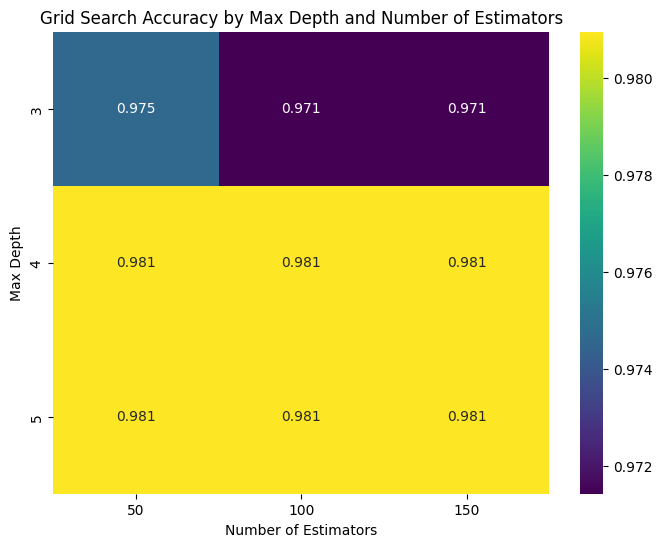

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True,
            fmt='.3f', cmap='viridis')
plt.title(
    'Grid Search Accuracy by Max Depth and Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()

Heatmap membantu melihat perubahan accuracy pada kombinasi hyperparameter yang berbeda. Pada materi, setelah `max_depth` dan `n_estimators` berada di atas nilai tertentu, accuracy tidak lagi meningkat.

### Hands-on Exercises

Langkah latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset untuk klasifikasi.
3. Bagi data menjadi training dan testing.
4. Definisikan hyperparameter grid sesuai model.
5. Terapkan `GridSearchCV()` atau `RandomizedSearchCV()`.
6. Evaluasi model terbaik pada test dataset.
7. Visualisasikan hasil tuning untuk memahami efek hyperparameter.

## 5. Comparing Ensemble Methods

Perbandingan ensemble methods membantu memahami kekuatan dan kelemahan dari bagging, boosting, dan stacking. Bagging mengurangi variance, boosting mengurangi bias, sedangkan stacking menggabungkan beberapa algoritma menggunakan meta-model untuk meningkatkan performa prediksi.

### Getting Ready

In [48]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [49]:
iris = load_iris()
X = iris.data
y = iris.target

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)

### How to Do It

In [51]:
rf_clf = RandomForestClassifier(
    n_estimators=100, random_state=2024
)
gb_clf = GradientBoostingClassifier(
    n_estimators=100, random_state=2024
)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    final_estimator=LogisticRegression(),
    cv=5
)

In [52]:
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(random_state=2024)),
                               ('gb',
                                GradientBoostingClassifier(random_state=2024))],
                   final_estimator=LogisticRegression())

In [53]:
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
stacking_pred = stacking_clf.predict(X_test)

In [54]:
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

In [55]:
print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.2f}')
print(f'Stacking Accuracy: {stacking_accuracy:.2f}')

Random Forest Accuracy: 0.91
Gradient Boosting Accuracy: 0.87
Stacking Accuracy: 0.87


Pada materi, random forest mengungguli GBM dan stacking.

### How It Works

- **Bagging** dengan random forest merata-ratakan prediksi dari banyak tree yang dibuat dari bootstrapped datasets sehingga variance berkurang.
- **Boosting** dengan GBM membangun tree secara berurutan untuk memperbaiki error model sebelumnya sehingga bias berkurang.
- **Stacking** menggabungkan beberapa base model menggunakan meta-model.

### Visualisasi Perbandingan Accuracy

In [56]:
import matplotlib.pyplot as plt

In [57]:
methods = [
    'Random Forest', 'Gradient Boosting', 'Stacking'
]
accuracies = [
    rf_accuracy, gb_accuracy, stacking_accuracy
]

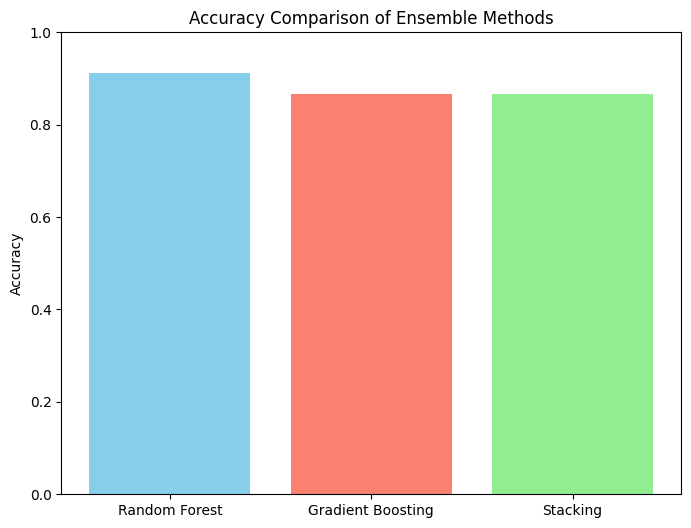

In [58]:
plt.figure(figsize=(8, 6))
plt.bar(methods, accuracies, color=['skyblue',
        'salmon', 'lightgreen'])
plt.title('Accuracy Comparison of Ensemble Methods')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

Bar chart menunjukkan performa relatif dari setiap metode ensemble.

### Hands-on Exercises

Langkah latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih beberapa dataset klasifikasi.
3. Bagi dataset menjadi training dan testing.
4. Latih classifier bagging, boosting, dan stacking.
5. Buat prediksi dan evaluasi setiap metode menggunakan beberapa metrik performa.
6. Visualisasikan hasil perbandingan untuk memahami kekuatan dan kelemahan setiap metode.

## 6. Practical Exercises with Tree-Based Models

Latihan akhir pada materi ini mencakup pembangunan, tuning, dan evaluasi model tree-based serta ensemble pada dataset nyata.

### Exercise 1: Building and Evaluating a Decision Tree Classifier

Langkah implementasi:
1. Load library.
2. Load dataset.
3. Split data.
4. Buat dan latih classifier.
5. Buat prediksi.
6. Evaluasi performa.

### Exercise 2: Hyperparameter Tuning with Random Forests

Langkah implementasi:
1. Load library.
2. Load dataset.
3. Split data.
4. Definisikan hyperparameter grid dan lakukan grid search.
5. Evaluasi model terbaik.

### Exercise 3: Comparing Gradient Boosting and Random Forest

Langkah implementasi:
1. Load library.
2. Load dataset.
3. Split data.
4. Buat dan latih model.
5. Buat prediksi dan evaluasi.